In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

pd.set_option('display.max_columns', None)

print("Performance Analytics Environment Initiated")


Performance Analytics Environment Initiated


In [17]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav_wide = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(nav_wide.shape)

nav_wide.head()

(1150, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,118633,118634,118635,118636,119092,119093,119094,119095,119120,119551,119552,119598,119599,120503,120504,120505,120506,120507,120841,120842,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,47.1836,69.1076,170.3428,30.1152,38.7466,41.8140,68.3023,52.5238,42.1391,54.3856,58.4174,89.8738,96.4565,55.3983,60.1474,135.8720,202.0453,285.7447,275.8370,62.1265,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,46.4910,68.8538,168.6874,30.2094,38.4924,41.8062,68.0566,53.5090,42.2508,54.3474,57.3480,88.5495,94.6512,55.6327,59.4577,133.1682,202.1501,285.8820,276.8163,63.2031,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,45.9945,69.0511,166.3925,30.2116,38.2033,41.6865,69.1860,54.5737,42.4374,54.6869,57.0552,88.0925,94.5436,55.9527,60.2855,137.2101,203.6057,286.0699,276.3892,64.1764,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,46.0047,68.4476,167.0030,30.2180,38.5825,41.2775,69.1690,54.5502,42.5901,55.4550,56.4224,88.5175,93.7944,56.6067,60.5202,136.5355,202.2714,286.1089,278.9247,64.4521,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,46.3033,67.0371,167.4910,30.2240,38.9425,41.6166,67.8877,56.3221,42.4851,55.3692,57.2750,91.4235,89.6438,57.5741,60.6373,137.8537,203.3482,286.2836,281.1488,64.2674,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [18]:
daily_returns = nav_wide.pct_change()

daily_returns = daily_returns.dropna()

print(daily_returns.shape)

daily_returns.head()

(1149, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,118633,118634,118635,118636,119092,119093,119094,119095,119120,119551,119552,119598,119599,120503,120504,120505,120506,120507,120841,120842,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,-0.014679,-0.003673,-0.009718,0.003128,-0.006561,-0.000187,-0.003597,0.018757,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.004231,-0.011467,-0.019900,0.000519,0.000480,0.003550,0.017329,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,-0.010679,0.002865,-0.013604,0.000073,-0.007511,-0.002863,0.016595,0.019898,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.005752,0.013923,0.030352,0.007201,0.000657,-0.001543,0.015400,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,0.000222,-0.008740,0.003669,0.000212,0.009926,-0.009811,-0.000246,-0.000431,0.003598,0.014045,-0.011091,0.004824,-0.007924,0.011688,0.003893,-0.004917,-0.006553,0.000136,0.009174,0.004296,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,0.006491,-0.020607,0.002922,0.000199,0.009331,0.008215,-0.018524,0.032482,-0.002465,-0.001547,0.015111,0.032830,-0.044252,0.017090,0.001935,0.009655,0.005324,0.000611,0.007974,-0.002866,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,-0.025402,-0.023268,-0.013569,0.003563,-0.009961,0.005685,-0.006878,0.026144,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.001617,0.014867,0.000252,0.003160,0.000958,-0.021464,-0.000801,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


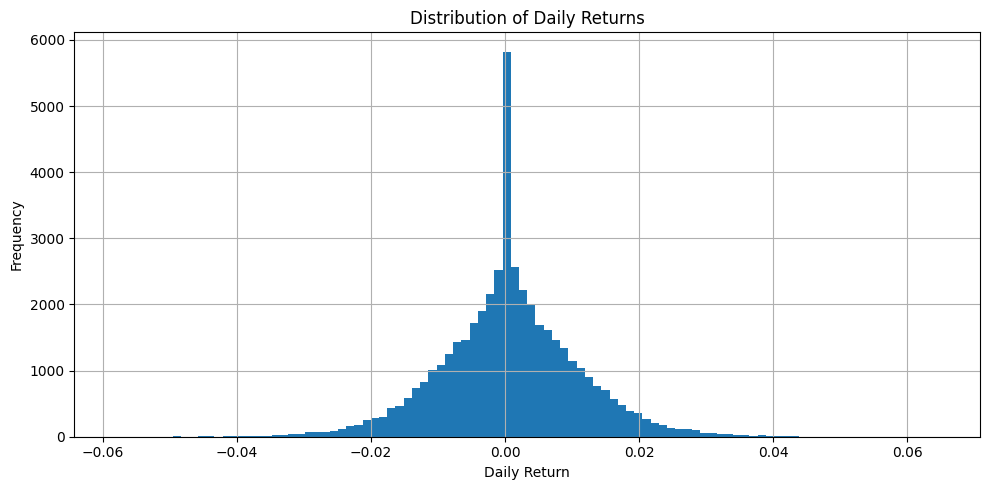

In [19]:
plt.figure(figsize=(10,5))

daily_returns.stack().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Finding 1: Daily Returns Distribution

The distribution of daily returns exhibits a near-normal bell-shaped pattern centered around zero. Most daily NAV movements fall within ±2%, while extreme returns are rare. This confirms that the NAV dataset is clean and suitable for advanced performance analytics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown calculations.

In [20]:
plt.figure(figsize=(10,5))

daily_returns.stack().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../Reports/charts/daily_returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Daily Returns Distribution chart saved successfully")

Daily Returns Distribution chart saved successfully


In [21]:
print(nav_wide.shape)
print(daily_returns.shape)

(1150, 40)
(1149, 40)
